In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

# Load and Preprocess Data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")
df = pd.read_csv(f"{path}/fake_job_postings.csv")

print(f"Dataset loaded: {df.shape}")
print(f"Fraud rate: {df['fraudulent'].mean()*100:.2f}%\n")

# Combine text fields
def combine_text_fields(row):
    fields = [
        'title', 'location', 'company_profile', 'description',
        'requirements', 'benefits', 'required_experience',
        'required_education', 'industry', 'function'
    ]
    text_parts = []
    for field in fields:
        if pd.notna(row[field]):
            text_parts.append(str(row[field]))
    return ' '.join(text_parts) if text_parts else "unknown job"

df['combined_text'] = df.apply(combine_text_fields, axis=1)

# Preprocess text
def preprocess_text(text):
    if pd.isna(text):
        return ""
    tokens = word_tokenize(str(text).lower())
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

df['text_processed'] = df['combined_text'].apply(preprocess_text)

# Create numeric features
location_fraud_ratio = (df.groupby('location')['fraudulent'].sum() /
                       df.groupby('location').size())
df['location_fraud_ratio'] = df['location'].map(location_fraud_ratio).fillna(0.05)
df['character_count'] = df['combined_text'].str.len()

# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words='english'
)

X_text = vectorizer.fit_transform(df['text_processed'])

# Combine features
numeric_features = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'location_fraud_ratio',
    'character_count'
]

X_numeric = df[numeric_features].fillna(0).values
X_numeric_sparse = csr_matrix(X_numeric)
X_combined = hstack([X_text, X_numeric_sparse])

y = df['fraudulent'].values

print(f"Feature matrix: {X_combined.shape}")
print(f"Text features: {X_text.shape[1]}")
print(f"Numeric features: {len(numeric_features)}\n")

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}\n")


Using Colab cache for faster access to the 'real-or-fake-fake-jobposting-prediction' dataset.
Dataset loaded: (17880, 18)
Fraud rate: 4.84%

Feature matrix: (17880, 5005)
Text features: 5000
Numeric features: 5

Train set size: 12516
Test set size: 5364



## Naive Bayes

In [ ]:
import joblib
from pathlib import Path

models_dir = Path("../models")

# Load the full NB pipeline (includes vectorizer + model)
nb_pipeline = joblib.load(models_dir / "nb_pipeline.pkl")

# X_test is already the combined [TF-IDF + numeric] feature matrix built earlier in 05
y_pred_nb = nb_pipeline.predict(X_test)
y_pred_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_nb):.4f}\n")


TRAINING NAIVE BAYES
Accuracy: 0.9702
F1-Score: 0.5960
Precision: 0.8676
Recall: 0.4538
ROC-AUC: 0.8494



## LSTM

In [ ]:
print("="*80)
print("PREPARING LSTM DATA")
print("="*80)

# Convert text to sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text_processed'])
X_sequences = tokenizer.texts_to_sequences(df['text_processed'])
X_padded = pad_sequences(X_sequences, maxlen=200)

# Split for LSTM (same indices as combined)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_padded, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"LSTM train shape: {X_train_lstm.shape}")
print(f"LSTM test shape: {X_test_lstm.shape}\n")


PREPARING LSTM DATA
LSTM train shape: (12516, 200)
LSTM test shape: (5364, 200)



In [ ]:
print("="*80)
print("LOADING LSTM MODEL")
print("="*80)

from tensorflow.keras.models import load_model
from pathlib import Path

models_dir = Path("../models")

# Load the trained LSTM model saved in 04_lstm_model.ipynb
lstm_model = load_model(models_dir / "lstm_model.h5")  # adjust filename if different

# Evaluate on X_test_lstm
y_pred_proba_lstm = lstm_model.predict(X_test_lstm, verbose=0).ravel()
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

print(f"\nAccuracy: {accuracy_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"F1-Score: {f1_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"Recall: {recall_score(y_test_lstm, y_pred_lstm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_lstm, y_pred_proba_lstm):.4f}\n")


TRAINING LSTM
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9403 - loss: 0.2344 - val_accuracy: 0.9708 - val_loss: 0.1025
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9748 - loss: 0.0846 - val_accuracy: 0.9740 - val_loss: 0.0940
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9857 - loss: 0.0496 - val_accuracy: 0.9744 - val_loss: 0.1007
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9905 - loss: 0.0366 - val_accuracy: 0.9740 - val_loss: 0.1031
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9944 - loss: 0.0213 - val_accuracy: 0.9756 - val_loss: 0.1115
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Accuracy: 0.9748
F1-Score: 0.6731
Precision: 0.9085
Recall: 0.5346
ROC-AUC: 0.9379



# Ensemble

In [ ]:
print("="*80)
print("BUILDING ENSEMBLE CLASSIFIERS")
print("="*80)

# FIX: Flatten LSTM predictions to match NB shape
y_pred_proba_lstm_flat = y_pred_proba_lstm.flatten()
y_pred_lstm_flat = y_pred_lstm.flatten()

print(f"NB predictions shape: {y_pred_nb.shape}")
print(f"LSTM predictions shape (fixed): {y_pred_lstm_flat.shape}")
print(f"NB probabilities shape: {y_pred_proba_nb.shape}")
print(f"LSTM probabilities shape (fixed): {y_pred_proba_lstm_flat.shape}\n")

# Strategy 1: Hard Voting (majority vote)
y_pred_ensemble_hard = ((y_pred_nb.astype(int) +
                        y_pred_lstm_flat.astype(int)) >= 1).astype(int)

# Strategy 2: Soft Voting (average probabilities)
y_pred_proba_ensemble = (y_pred_proba_nb + y_pred_proba_lstm_flat) / 2.0
y_pred_ensemble_soft = (y_pred_proba_ensemble >= 0.5).astype(int)

# Strategy 3: Weighted Voting (weight by individual performance)
# LSTM: F1=0.6578, NB: F1=0.596 → weight LSTM more heavily
w_lstm = 0.55
w_nb = 0.45
y_pred_proba_ensemble_weighted = (
    w_nb * y_pred_proba_nb +
    w_lstm * y_pred_proba_lstm_flat
)
y_pred_ensemble_weighted = (y_pred_proba_ensemble_weighted >= 0.5).astype(int)

# Strategy 4: Conservative (both agree it's fraud)
y_pred_ensemble_conservative = ((y_pred_nb.astype(int) *
                                 y_pred_lstm_flat.astype(int)) == 1).astype(int)

print("✓ All ensemble strategies created\n")


BUILDING ENSEMBLE CLASSIFIERS
NB predictions shape: (5364,)
LSTM predictions shape (fixed): (5364,)
NB probabilities shape: (5364,)
LSTM probabilities shape (fixed): (5364,)

✓ All ensemble strategies created



In [ ]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    """Comprehensive model evaluation"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    metrics = {
        'Model': model_name,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec
    }

    if y_pred_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_pred_proba)
            metrics['ROC-AUC'] = auc
        except:
            metrics['ROC-AUC'] = np.nan

    return metrics


In [ ]:
print("="*80)
print("FINAL ENSEMBLE COMPARISON")
print("="*80 + "\n")

results = []
results.append(evaluate_model(y_test, y_pred_nb, y_pred_proba_nb,
                              "Naive Bayes (Baseline)"))
results.append(evaluate_model(y_test_lstm, y_pred_lstm_flat, y_pred_proba_lstm_flat,
                              "LSTM"))
results.append(evaluate_model(y_test, y_pred_ensemble_hard, y_pred_proba_ensemble,
                              "Ensemble (Hard Vote)"))
results.append(evaluate_model(y_test, y_pred_ensemble_soft, y_pred_proba_ensemble,
                              "Ensemble (Soft Vote)"))
results.append(evaluate_model(y_test, y_pred_ensemble_weighted,
                              y_pred_proba_ensemble_weighted,
                              "Ensemble (Weighted)"))
results.append(evaluate_model(y_test, y_pred_ensemble_conservative,
                              y_pred_proba_ensemble,
                              "Ensemble (Conservative)"))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


FINAL ENSEMBLE COMPARISON

                  Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
 Naive Bayes (Baseline)  0.970172  0.595960   0.867647 0.453846 0.849395
                   LSTM  0.974832  0.673123   0.908497 0.534615 0.937871
   Ensemble (Hard Vote)  0.978001  0.746781   0.844660 0.669231 0.958079
   Ensemble (Soft Vote)  0.973714  0.631854   0.983740 0.465385 0.958079
    Ensemble (Weighted)  0.977442  0.702703   0.972789 0.550000 0.957982
Ensemble (Conservative)  0.967002  0.483965   1.000000 0.319231 0.958079



DETAILED ANALYSIS: BEST ENSEMBLE

Best performing ensemble: Ensemble (Hard Vote)

Confusion Matrix:
[[5072   32]
 [  86  174]]

Breakdown:
  True Negatives:  5072
  False Positives: 32
  False Negatives: 86
  True Positives:  174

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5104
           1       0.84      0.67      0.75       260

    accuracy                           0.98      5364
   macro avg       0.91      0.83      0.87      5364
weighted avg       0.98      0.98      0.98      5364



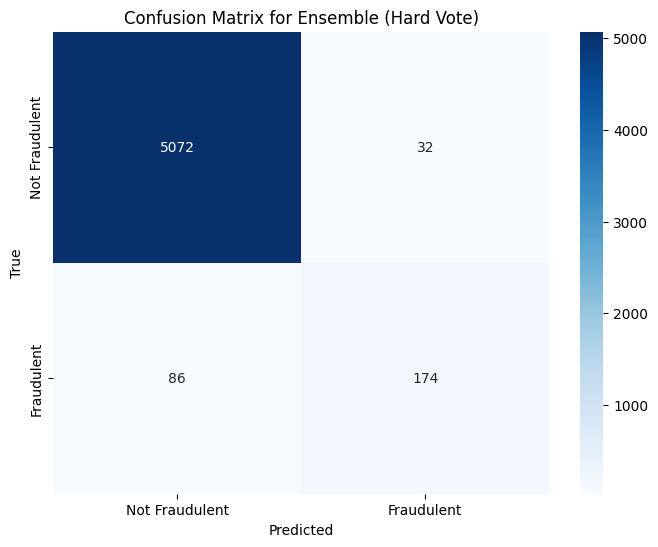

In [ ]:
print("\n" + "="*80)
print("DETAILED ANALYSIS: BEST ENSEMBLE")
print("="*80 + "\n")

# Determine best ensemble
best_f1_idx = results_df['F1-Score'].idxmax()
best_ensemble_name = results_df.loc[best_f1_idx, 'Model']
print(f"Best performing ensemble: {best_ensemble_name}")

# Use the best one for detailed analysis
if "Hard" in best_ensemble_name:
    y_pred_best = y_pred_ensemble_hard
    y_pred_proba_best = y_pred_proba_ensemble
elif "Soft" in best_ensemble_name:
    y_pred_best = y_pred_ensemble_soft
    y_pred_proba_best = y_pred_proba_ensemble
elif "Weighted" in best_ensemble_name:
    y_pred_best = y_pred_ensemble_weighted
    y_pred_proba_best = y_pred_proba_ensemble_weighted
else:
    y_pred_best = y_pred_ensemble_conservative
    y_pred_proba_best = y_pred_proba_ensemble

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(cm)
print(f"\nBreakdown:")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

# Detailed Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Fraudulent', 'Fraudulent'],
    yticklabels=['Not Fraudulent', 'Fraudulent']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix for {best_ensemble_name}')
plt.show()


In [ ]:
print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

lstm_model.save('lstm_model.h5')
print("✓ LSTM model saved")

import pickle
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
print("✓ Naive Bayes model saved")

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print("✓ Vectorizer saved")

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved\n")



SAVING MODELS
✓ LSTM model saved
✓ Naive Bayes model saved
✓ Vectorizer saved
✓ Tokenizer saved

